# 02. 전처리 및 탐색적 데이터 분석 (Preprocessing & EDA)

이 노트북에서는 다음 작업을 수행합니다:
1. 결측치 처리
2. 이상치 제거
3. 파생변수 생성 (BMI, 위험요인 플래그 등)
4. EDA 시각화

In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

## 1. 전처리 파이프라인 실행

In [2]:
# src/preprocessing.py의 함수들 사용
from src.preprocessing import run_full_preprocessing

df = run_full_preprocessing('../data/raw/2024_국민건강보험공단_건강검진정보.CSV')
print(f'\n최종: {df.shape[0]:,}행 × {df.shape[1]}열')
df.head()

[load_raw_data] 원본 데이터 크기: 1,000,000행 × 33열
[select_model_columns] 선택된 컬럼: ['gender', 'age_group', 'region_code', 'height_cm', 'weight_kg', 'waist_cm', 'systolic_bp', 'diastolic_bp', 'fasting_glucose', 'smoking_status', 'drinking']
[handle_missing_values] 필수값 결측 제거: 1,000,000 → 1,000,000행
[handle_missing_values] 처리 후 남은 결측치: 0개
[remove_outliers] 이상치 제거: 1,000,000 → 999,777행
[engineer_features] 파생변수 생성 완료: bmi, bmi_category, age_label, hypertension_flag, hyperglycemia_flag, abdominal_obesity_flag, obesity_flag, metabolic_risk_count

✅ 전처리 완료: 최종 999,777행 × 19열

최종: 999,777행 × 19열


,gender,age_group,region_code,height_cm,weight_kg,waist_cm,systolic_bp,diastolic_bp,fasting_glucose,smoking_status,drinking,bmi,bmi_category,age_label,hypertension_flag,hyperglycemia_flag,abdominal_obesity_flag,obesity_flag,metabolic_risk_count
0,2,13,41,160,50,70.0,107.0,77.0,70.0,1.0,1.0,19.5,1,65-69세,0,0,0,0,0
1,2,11,41,155,60,74.9,104.0,69.0,81.0,1.0,1.0,25.0,3,55-59세,0,0,0,1,1
2,2,13,41,150,55,74.0,134.0,83.0,106.0,1.0,1.0,24.4,2,65-69세,1,1,0,0,2
3,1,16,41,160,70,89.0,119.0,73.0,97.0,1.0,1.0,27.3,3,80-84세,0,0,0,1,1
4,1,11,41,175,65,76.0,103.0,64.0,115.0,1.0,1.0,21.2,1,55-59세,0,1,0,0,1


## 2. 파생변수 분포 확인

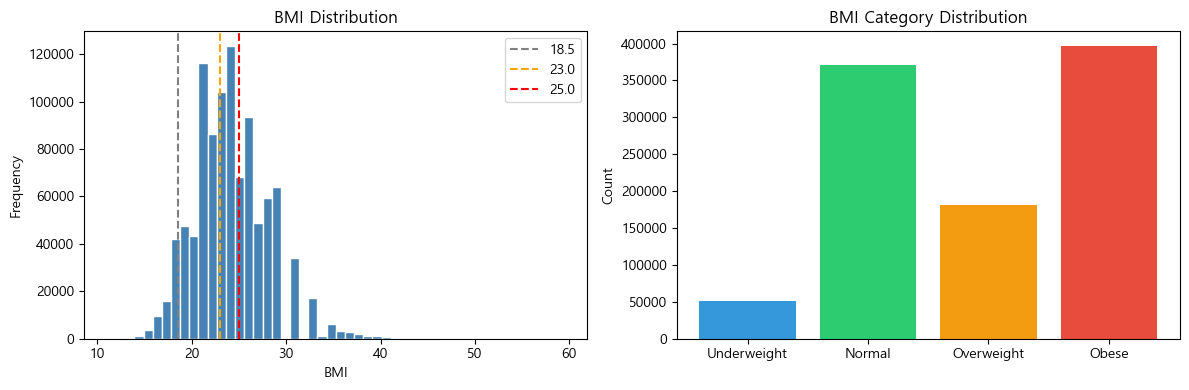

In [3]:
# BMI 분포
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['bmi'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(18.5, color='gray', linestyle='--', label='18.5')
axes[0].axvline(23.0, color='orange', linestyle='--', label='23.0')
axes[0].axvline(25.0, color='red', linestyle='--', label='25.0')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Frequency')
axes[0].set_title('BMI Distribution')
axes[0].legend()

# BMI 카테고리 분포
cat_labels = ['Underweight', 'Normal', 'Overweight', 'Obese']
cat_counts = df['bmi_category'].value_counts().sort_index()
axes[1].bar(cat_labels, cat_counts.values, color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c'])
axes[1].set_ylabel('Count')
axes[1].set_title('BMI Category Distribution')

plt.tight_layout()
plt.show()

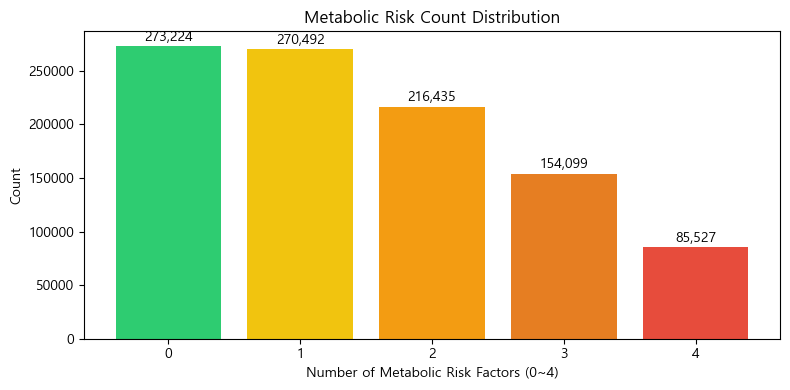

In [4]:
# 위험요인 개수 분포
fig, ax = plt.subplots(figsize=(8, 4))
risk_counts = df['metabolic_risk_count'].value_counts().sort_index()
ax.bar(risk_counts.index, risk_counts.values,
       color=['#2ecc71', '#f1c40f', '#f39c12', '#e67e22', '#e74c3c'])
ax.set_xlabel('Number of Metabolic Risk Factors (0~4)')
ax.set_ylabel('Count')
ax.set_title('Metabolic Risk Count Distribution')
for i, v in enumerate(risk_counts.values):
    ax.text(i, v + 5000, f'{v:,}', ha='center')
plt.tight_layout()
plt.show()

## 3. 성별·연령대별 주요 변수 비교

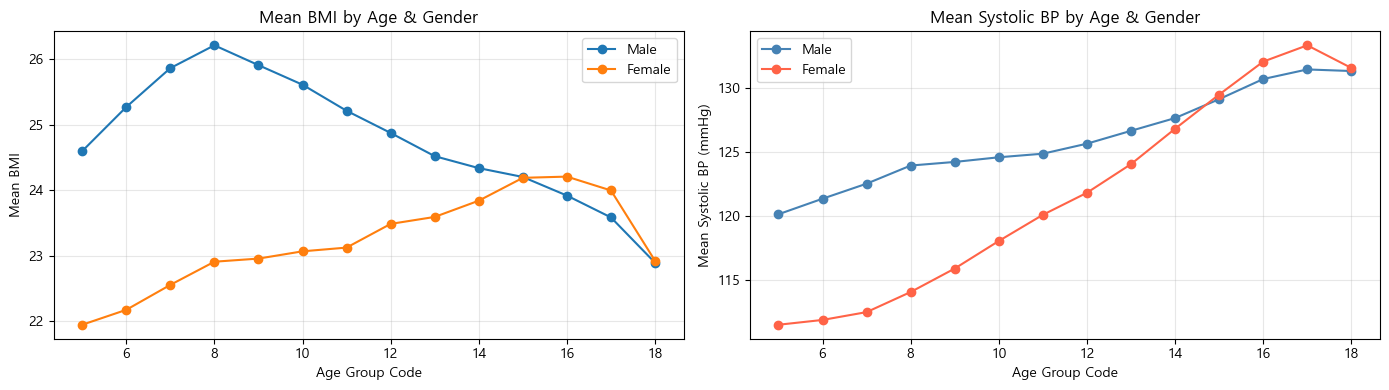

In [5]:
# 연령대별 평균 BMI/혈압
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# BMI by age & gender
bmi_by_age = df.groupby(['age_group', 'gender'])['bmi'].mean().unstack()
bmi_by_age.columns = ['Male', 'Female']
bmi_by_age.plot(ax=axes[0], marker='o')
axes[0].set_xlabel('Age Group Code')
axes[0].set_ylabel('Mean BMI')
axes[0].set_title('Mean BMI by Age & Gender')
axes[0].grid(alpha=0.3)

# SBP by age & gender
sbp_by_age = df.groupby(['age_group', 'gender'])['systolic_bp'].mean().unstack()
sbp_by_age.columns = ['Male', 'Female']
sbp_by_age.plot(ax=axes[1], marker='o', color=['steelblue', 'tomato'])
axes[1].set_xlabel('Age Group Code')
axes[1].set_ylabel('Mean Systolic BP (mmHg)')
axes[1].set_title('Mean Systolic BP by Age & Gender')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

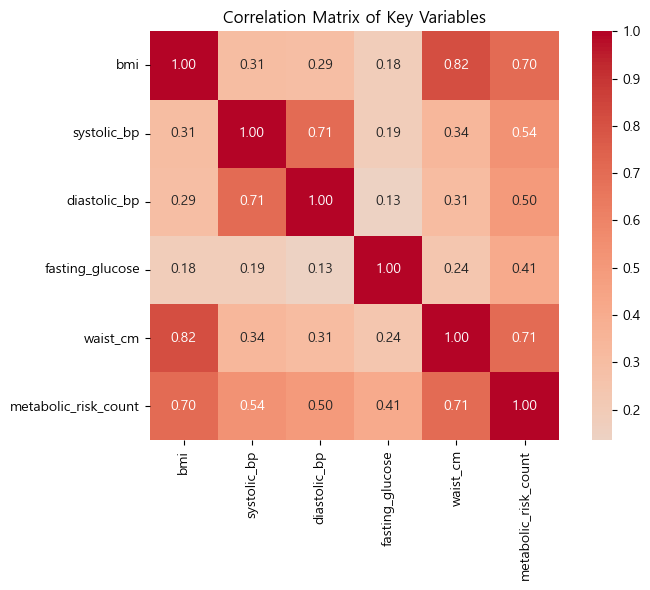

In [6]:
# 변수 간 상관관계
corr_cols = ['bmi', 'systolic_bp', 'diastolic_bp',
             'fasting_glucose', 'waist_cm', 'metabolic_risk_count']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True)
ax.set_title('Correlation Matrix of Key Variables')
plt.tight_layout()
plt.show()

## 결론

- **이상치 제거**: 100만 건 → 약 99.98% 보존 (이상치 0.02% 제거)
- **BMI 분포**: 정상~과체중에 다수 분포, 비만(BMI≥25) 약 35%
- **위험요인 분포**: 0개 ~ 4개로 자연스러운 분포
- **상관관계**: BMI ↔ 혈압/허리둘레 간 약한~중간 양의 상관
- **다음 단계**: 03_clustering_modeling.ipynb에서 룰 기반 라벨링